In [ ]:
import numpy as np
import pandas as pd
import zarr
import os

path = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122"

path0 = os.path.join(path, "exp")
path1 = os.path.join(path, "exp001")
path2 = os.path.join(path, "exp002")

Ps = []
GPs = []

for p in [path0, path1, path2]:
    track_path = os.path.join(p, "beads_tracks_with_local_P.csv")
    tracks = pd.read_csv(track_path)
    Ps.extend(tracks['local_P'].values)

    globalP = os.path.join(path, "MTs_red_polar.zarr")
    GP_array = zarr.open_array(globalP, mode='r')
    GPs.extend(GP_array[:])

Text(0.5, 1.0, 'Distribution of Local Polar Order Parameters')

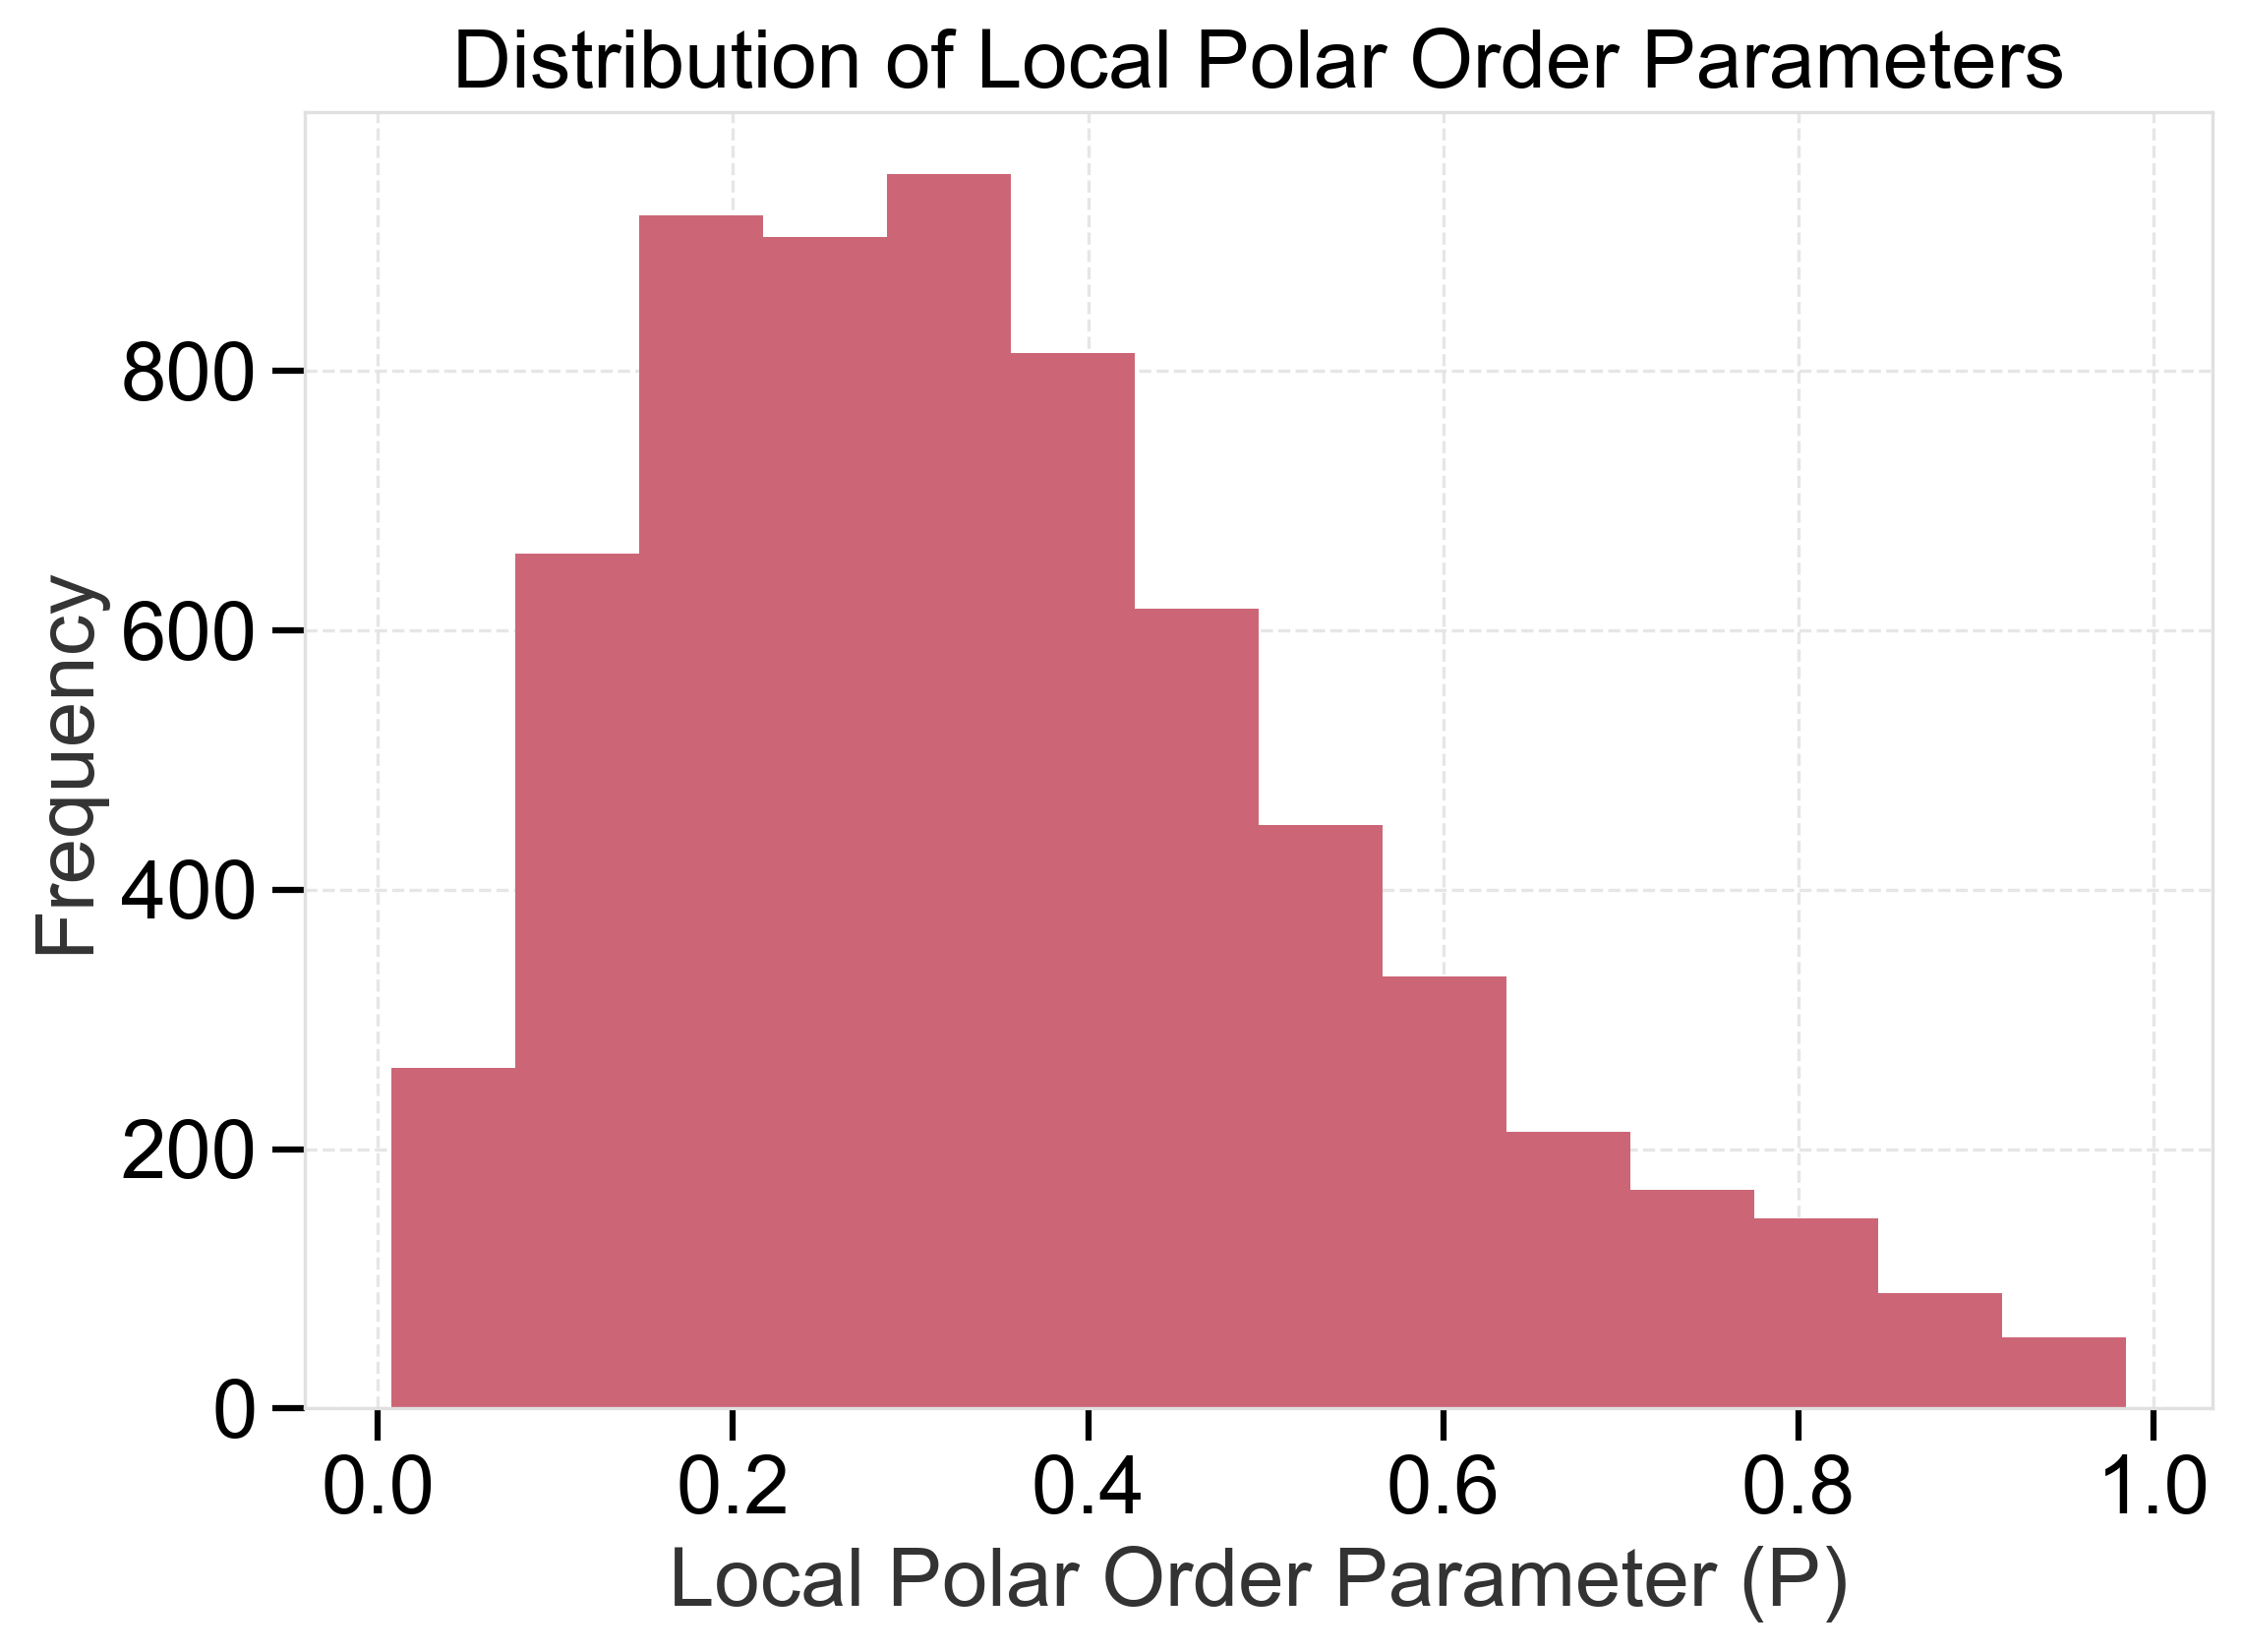

In [118]:
import matplotlib.pyplot as plt

plt.style.use('../libs/my_style.mplstyle')

Ps_array = np.array(Ps)
# Nanを除去
Ps_array = Ps_array[~np.isnan(Ps_array)]

bins = np.histogram_bin_edges(Ps_array, bins='sturges')

fig, ax = plt.subplots()

ax.hist(Ps_array, bins=bins)
ax.set_xlabel('Local Polar Order Parameter (P)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Local Polar Order Parameters')

In [119]:
zarr002  = zarr.open_array(os.path.join(path2, "MTs_red_flow.zarr"), mode='r')
track002 = pd.read_csv(os.path.join(path2, "beads_tracks_with_local_P.csv"))

In [120]:
track002

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle,local_P
0,260.313809,1555.458968,123343.574934,18.557424,0.262614,92.682352,1480350.0,NaN,0,0,0.518436
1,610.080017,1771.039309,146403.657000,23.411215,0.039700,66.937254,1677296.0,NaN,0,1,0.238660
2,1054.428969,768.156444,168736.142997,24.417097,0.117782,67.729411,1739208.0,NaN,0,3,0.694144
3,1292.011746,231.496726,165130.641081,27.140123,0.090122,58.619607,1778461.0,NaN,0,4,0.402079
4,1290.878710,234.903081,170992.947355,27.504694,0.096053,57.567845,1784994.0,NaN,1,4,0.404600
...,...,...,...,...,...,...,...,...,...,...,...
4003,1029.940611,492.420579,183783.759476,21.619387,0.054558,85.681985,1581664.0,NaN,1000,3,0.133326
4004,175.511192,1530.572145,128419.913439,19.657306,0.295382,91.776069,1504761.0,NaN,1001,0,NaN
4005,536.527058,1327.201744,168112.883167,23.821720,0.076598,69.821793,1704739.0,NaN,1001,1,NaN
4006,1030.296407,498.529560,168170.828058,20.927546,0.060420,83.138321,1593524.0,NaN,1001,3,NaN


In [ ]:
plt